<a href="https://colab.research.google.com/github/najadsayshi/bioinformatics/blob/main/lunar_lander.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gymnasium[box2d] torch matplotlib numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 30.9 MB/s eta 0:00:00


In [3]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque, namedtuple


In [5]:
env = gym.make("LunarLander-v3")
state,info = env.reset()
print(f"state: {state}")
print(f"state shape: {state.shape}")
print(f"Number of actions: {env.action_space.n}")
env.close()

state: [-0.00224905  1.3996177  -0.22782454 -0.50232255  0.00261292  0.05160566
  0.          0.        ]
state shape: (8,)
Number of actions: 4


In [9]:
env = gym.make("LunarLander-v3")
state,info=env.reset()
score = 0
done = False

steps = 0

while not done:
  action = env.action_space.sample()
  state, reward, terminated, truncated, info = env.step(action)
  done = terminated or truncated
  score += reward
  steps += 1

print(f"Game lasted {steps} steps")
print(f"Final score: {score}")
print("thats bad,isnt it,anything below 200 is bad")
env.close()

Game lasted 66 steps
Final score: -199.8544914016811
thats bad,isnt it,anything below 200 is bad


In [83]:
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_size)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


In [84]:
test_net = QNetwork(state_size=8, action_size=4)
fake_state = torch.FloatTensor([0.1, 1.4, -0.3, 0.0, 0.05, 0.0, 0, 0]).unsqueeze(0)
output = test_net(fake_state)
print("Input:  8 numbers (the state)")
print("Output:", output.detach().numpy())
print("Best action:", output.argmax().item())


Input:  8 numbers (the state)
Output: [[-0.13011485  0.061905    0.08197349  0.0933146 ]]
Best action: 3


In [85]:
test_net = QNetwork(state_size=8,action_size=4)
real_state,info = env.reset()
real_state_tensor = torch.FloatTensor(real_state).unsqueeze(0)
output = test_net(real_state_tensor)
print("Input:  8 numbers (the state)")
print("Output:", output.detach().numpy())
print("Best action:", output.argmax().item())

Input:  8 numbers (the state)
Output: [[0.04834891 0.1723328  0.152192   0.19679773]]
Best action: 3


In [86]:
class ReplayBuffer:
    def __init__(self, buffer_size, batch_size):
        self.memory = deque(maxlen=buffer_size)
        self.batch_size = batch_size
        self.experience = namedtuple("Experience",
            ["state", "action", "reward", "next_state", "done"])

    def add(self, state, action, reward, next_state, done):
        e = self.experience(state, action, reward, next_state, done)
        self.memory.append(e)

    def sample(self):
        experiences = random.sample(self.memory, k=self.batch_size)

        states = torch.FloatTensor(np.array([e.state for e in experiences]))
        actions = torch.LongTensor(np.array([e.action for e in experiences])).unsqueeze(1)
        rewards = torch.FloatTensor(np.array([e.reward for e in experiences])).unsqueeze(1)
        next_states = torch.FloatTensor(np.array([e.next_state for e in experiences]))
        dones = torch.FloatTensor(np.array([e.done for e in experiences]).astype(np.uint8)).unsqueeze(1)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.memory)


In [87]:
buf = ReplayBuffer(buffer_size=1000, batch_size=4)

# Pretend the spaceship had 10 experiences
for i in range(10):
    fake_s = np.random.randn(8)      # random state
    fake_a = random.randint(0, 3)    # random action
    fake_r = random.random()         # random reward
    fake_ns = np.random.randn(8)     # random next state
    buf.add(fake_s, fake_a, fake_r, fake_ns, False)

print(f"Buffer has {len(buf)} memories")

# Sample 4 random ones
states, actions, rewards, next_states, dones = buf.sample()
print(f"Sampled states shape: {states.shape}")
print(f"Sampled actions: {actions.squeeze().tolist()}")


Buffer has 10 memories
Sampled states shape: torch.Size([4, 8])
Sampled actions: [2, 2, 0, 1]


In [96]:
class DQNAgent:
  def __init__(self,state_size,action_size):
    self.state_size = state_size
    self.action_size = action_size

    self.gamma = 0.99
    self.lr = 5e-4
    self.tau = 1e-3
    self.batch_size = 64

    self.buffer_size = int(1e5) #10000
    self.update_every = 4
    self.qnetwork_local = QNetwork(state_size, action_size)
    self.qnetwork_target = QNetwork(state_size, action_size)
    self.qnetwork_target.load_state_dict(self.qnetwork_local.state_dict())

    self.optimizer = optim.Adam(self.qnetwork_local.parameters(), lr=self.lr)
    self.criterion = nn.MSELoss()

    #now we need to create a reply buffer for training data

    self.memory = ReplayBuffer(self.buffer_size, self.batch_size)
    self.t_step = 0

  def act(self,state,eps=0.0):
    state_tensor = torch.FloatTensor(state).unsqueeze(0)

    self.qnetwork_local.eval()
    with torch.no_grad():
      action_values = self.qnetwork_local(state_tensor)
    self.qnetwork_local.train()

    if random.random() > eps:
          return np.argmax(action_values.cpu().data.numpy())
    else:
        return random.choice(np.arange(self.action_size))

  def step(self,state,action,reward,next_state,done):
    self.memory.add(state,action,reward,next_state,done)
    self.t_step = (self.t_step+1) % self.update_every

    if self.t_step ==0 and len(self.memory)> self.batch_size:
      return self.learn()

    return None


  def learn(self):
      states, actions, rewards, next_states, dones = self.memory.sample()

      Q_targets_next = self.qnetwork_target(next_states).detach().max(1)[0].unsqueeze(1)

      Q_targets = rewards + (self.gamma * Q_targets_next * (1 - dones))

      Q_expected = self.qnetwork_local(states).gather(1, actions)

      loss = self.criterion(Q_expected, Q_targets)

      self.optimizer.zero_grad()
      loss.backward()
      self.optimizer.step()

      self.soft_update()

      return loss.item()


  def soft_update(self):
        for target_param, local_param in zip(
            self.qnetwork_target.parameters(),
            self.qnetwork_local.parameters()
        ):
            target_param.data.copy_(
                self.tau * local_param.data + (1.0 - self.tau) * target_param.data
            )



In [97]:
agent = DQNAgent(state_size=8, action_size=4)
print("Agent created!")
print(f"Memory capacity: {agent.buffer_size:,}")
print(f"Network params: {sum(p.numel() for p in agent.qnetwork_local.parameters()):,}")


Agent created!
Memory capacity: 100,000
Network params: 4,996


In [101]:

  def train_dqn(n_episodes=1000, eps_start=1.0, eps_end=0.01, eps_decay=0.995):
      env = gym.make('LunarLander-v3')

      scores = []
      losses = []
      eps = eps_start

      for i_episode in range(1, n_episodes + 1):
          state, _ = env.reset()
          score = 0
          episode_losses = []

          while True:
              action = agent.act(state, eps)
              next_state, reward, terminated, truncated, _ = env.step(action)
              done = terminated or truncated

              loss = agent.step(state, action, reward, next_state, done)
              if loss is not None:
                  episode_losses.append(loss)

              state = next_state
              score += reward

              if done:
                  break

          scores.append(score)
          avg_loss = np.mean(episode_losses) if episode_losses else 0
          losses.append(avg_loss)
          eps = max(eps_end, eps_decay * eps)

          if i_episode % 100 == 0:
              avg_score = np.mean(scores[-100:])
              print(f"Episode {i_episode} | Avg Score: {avg_score:.1f} | Epsilon: {eps:.4f}")

      env.close()
      return scores, losses

In [99]:
scores, losses = train_dqn(n_episodes=1000)



Episode 100 | Avg Score: -179.3 | Epsilon: 0.6058
Episode 200 | Avg Score: -133.2 | Epsilon: 0.3670
Episode 300 | Avg Score: -18.3 | Epsilon: 0.2223
Episode 400 | Avg Score: 89.9 | Epsilon: 0.1347
Episode 500 | Avg Score: 184.8 | Epsilon: 0.0816
Episode 600 | Avg Score: 218.2 | Epsilon: 0.0494
Episode 700 | Avg Score: 245.8 | Epsilon: 0.0299
Episode 800 | Avg Score: 243.9 | Epsilon: 0.0181
Episode 900 | Avg Score: 235.3 | Epsilon: 0.0110
Episode 1000 | Avg Score: 252.2 | Epsilon: 0.0100


FileNotFoundError: [Errno 2] No such file or directory: 'figures/results.png'

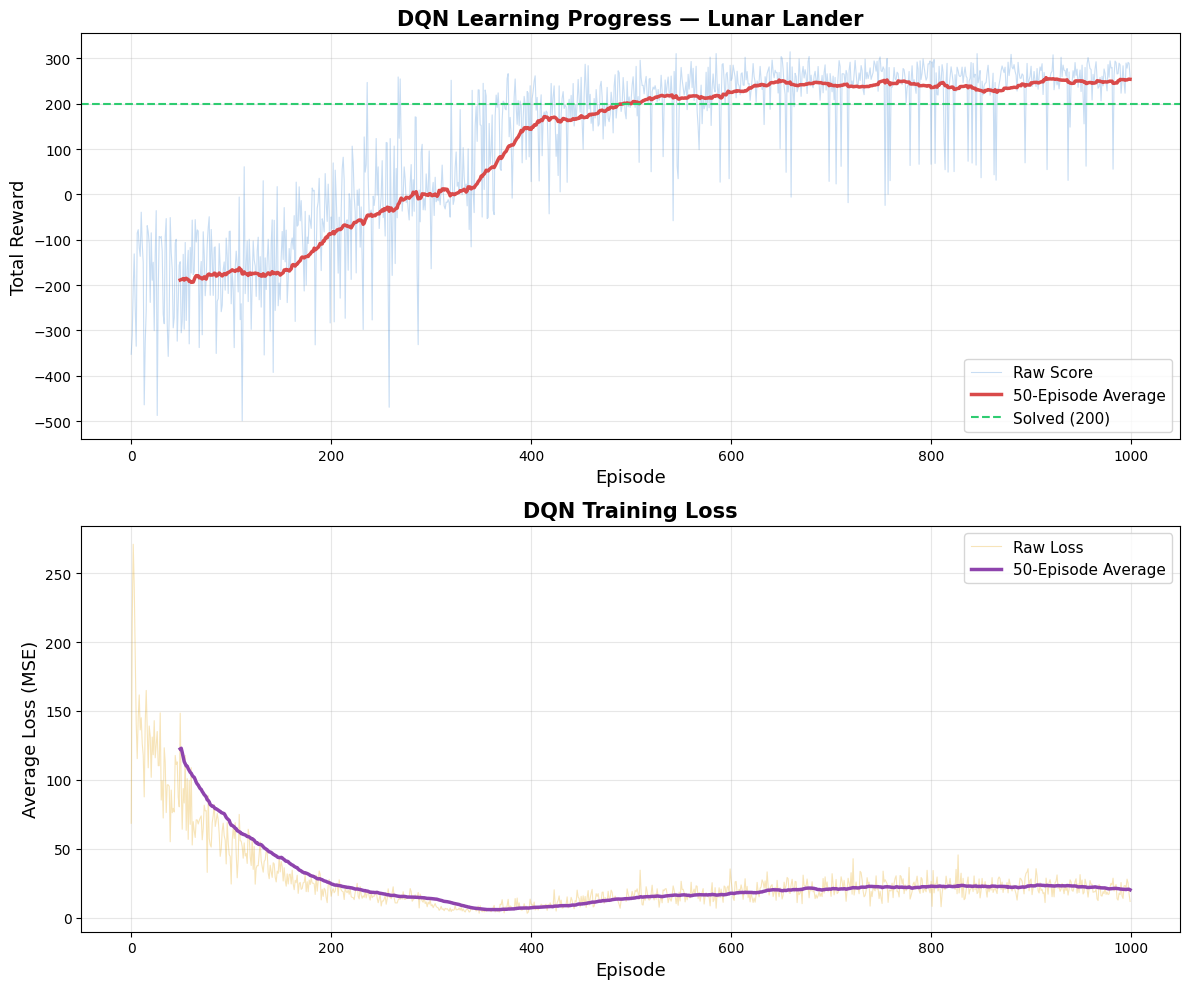

In [102]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Rewards
ax1.plot(scores, alpha=0.3, color='#4A90D9', linewidth=0.8, label='Raw Score')
moving_avg = np.convolve(scores, np.ones(50)/50, mode='valid')
ax1.plot(range(49, len(scores)), moving_avg, color='#D94A4A', linewidth=2.5, label='50-Episode Average')
ax1.axhline(y=200, color='#2ECC71', linestyle='--', linewidth=1.5, label='Solved (200)')
ax1.set_xlabel('Episode', fontsize=13)
ax1.set_ylabel('Total Reward', fontsize=13)
ax1.set_title('DQN Learning Progress — Lunar Lander', fontsize=15, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Loss
ax2.plot(losses, alpha=0.3, color='#E6A817', linewidth=0.8, label='Raw Loss')
moving_avg_loss = np.convolve(losses, np.ones(50)/50, mode='valid')
ax2.plot(range(49, len(losses)), moving_avg_loss, color='#8E44AD', linewidth=2.5, label='50-Episode Average')
ax2.set_xlabel('Episode', fontsize=13)
ax2.set_ylabel('Average Loss (MSE)', fontsize=13)
ax2.set_title('DQN Training Loss', fontsize=15, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/results.png', dpi=150)
plt.show()
print("Saved to figures/results.png")
